# Peak-to-Gene linkage in epione

`epione.tl.peak_to_gene` ports ArchR's [`addPeak2GeneLinks`](https://www.archrproject.com/bookdown/calculating-peak2genelinks-in-archr.html): given a paired (or gene-score-augmented) scATAC+scRNA dataset, it identifies peak-gene pairs whose accessibility and expression are correlated across cells.

**Algorithm** (identical to ArchR):

1. Take an embedding (here, `X_iterative_lsi` from `epione.tl.iterative_lsi`) and aggregate it into `n_metacells` pseudobulks via kNN.
2. Average the peak and gene matrices within each pseudobulk.
3. For every peak, find genes whose TSS is within ±`max_distance` bp of the peak centre.
4. Compute Pearson `r` across pseudobulks, convert to a t-statistic, and BH-FDR-adjust across all tested pairs.

In this notebook we run the full pipeline on the 10x Genomics PBMC-10k multiome dataset (paired scATAC + scRNA from the same cells).

In [1]:
%matplotlib inline
import os, pathlib
os.environ.setdefault('XDG_CACHE_HOME', '/scratch/users/steorra/cache')
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import snapatac2 as sa
import epione as ep

WORK = pathlib.Path('/scratch/users/steorra/data/pbmc10k_p2g')
WORK.mkdir(parents=True, exist_ok=True)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Impor

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /scratch/users/steorra/env/omicdev/lib/python3.10/site-packages
  warnings.warn(


## 1. Load the paired multiome data

snapatac2 bundles pre-processed `.h5ad` files for both modalities. Barcodes are shared between the two — we filter to the intersection.

In [2]:
atac_h5 = sa.datasets.pbmc10k_multiome(modality='ATAC', type='h5ad')
rna_h5  = sa.datasets.pbmc10k_multiome(modality='RNA',  type='h5ad')
print('atac:', atac_h5, '\nrna :', rna_h5)

atac = ad.read_h5ad(str(atac_h5))
rna  = ad.read_h5ad(str(rna_h5))
print(atac)
print(rna)

atac: /tmp/snapatac2/10x-Multiome-Pbmc10k-ATAC.h5ad 
rna : /tmp/snapatac2/10x-Multiome-Pbmc10k-RNA.h5ad


AnnData object with n_obs × n_vars = 9631 × 107194
    obs: 'domain', 'cell_type'
    var: 'feature_types'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap'
AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'cell_type'
    var: 'gene_ids', 'feature_types'


In [3]:
common = atac.obs_names.intersection(rna.obs_names)
atac = atac[common].copy()
rna  = rna[common].copy()
atac.obs['n_fragment'] = np.asarray(atac.X.sum(axis=1)).ravel()
print(f'shared cells: {len(common):,}; peaks: {atac.n_vars:,}; genes: {rna.n_vars:,}')

shared cells: 9,631; peaks: 107,194; genes: 29,095


## 2. Iterative LSI on the ATAC matrix

peak_to_gene needs an embedding to build the kNN pseudobulks from. Iterative LSI is the canonical choice for ATAC.

In [4]:
ep.tl.iterative_lsi(
    atac,
    n_components=30, iterations=2, var_features=25000,
    total_features=min(500000, atac.n_vars),
    resolution=0.5, n_neighbors=30,
    sample_cells_pre=10000, depth_col='n_fragment', seed=1,
)
print('embedding:', atac.obsm['X_iterative_lsi'].shape)

  └─ [iterative_lsi] Initial feature set: 106,658 / 107,194


  └─ [iterative_lsi] Iter 1/2 | fit on 9,631 cells x 106,658 features


  └─ [iterative_lsi]   -> 15 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 9,631 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (9,631 x 29) in adata.obsm['X_iterative_lsi']
embedding: (9631, 29)


## 3. Gene annotation (hg38 GTF)

We need per-gene coordinates to define the distance window. snapatac2 ships a GENCODE hg38 GTF and caches it under `$XDG_CACHE_HOME`. We load it once and turn it into a lean DataFrame (`gene_name, chrom, start, end, strand`).

In [5]:
gtf_path = sa.genome.hg38.annotation   # pathlib.Path to a gencode gff3.gz
print('GTF:', gtf_path)
import pyranges as pr
g = pr.read_gff3(str(gtf_path)).df
g = g[g['Feature'] == 'gene']
gene_ann = pd.DataFrame({
    'gene_name': g.get('gene_name', g.get('gene_id')).astype(str).values,
    'chrom':     g['Chromosome'].astype(str).values,
    'start':     g['Start'].astype(int).values,
    'end':       g['End'].astype(int).values,
    'strand':    g.get('Strand', '+').astype(str).values,
}).drop_duplicates('gene_name').reset_index(drop=True)
print(f'{len(gene_ann):,} annotated genes (hg38)')
gene_ann.head()

GTF: /tmp/snapatac2/gencode_v41_GRCh38.gff3.gz


60,606 annotated genes (hg38)


,gene_name,chrom,start,end,strand
0,DDX11L1,chr1,11868,14409,+
1,MIR1302-2HG,chr1,29553,31109,+
2,MIR1302-2,chr1,30365,30503,+
3,OR4G4P,chr1,52472,53312,+
4,OR4G11P,chr1,57597,64116,+


## 4. Run peak_to_gene

Defaults match ArchR: 500 pseudobulks × 100 neighbours, ±250 kb window, Pearson correlation, FDR correction.

In [6]:
links = ep.tl.peak_to_gene(
    atac,
    rna=rna,
    gene_annotation=gene_ann,
    use_rep='X_iterative_lsi',
    n_metacells=500, k_neighbors=100,
    max_distance=250_000,
    min_correlation=0.0,
    seed=1,
)
links.to_parquet(WORK / 'peak_to_gene.parquet')
print(f'{len(links):,} pairs, {(links.fdr < 0.05).sum():,} significant (FDR < 0.05)')

  └─ [peak_to_gene] 107,194 peaks | 20,169 annotated genes | 9,631 cells
  └─ [peak_to_gene] Building 500 metacells × 100 neighbours from X_iterative_lsi
  └─ [peak_to_gene] Aggregating peak matrix


  └─ [peak_to_gene] Aggregating gene matrix


  └─ [peak_to_gene] Finding peak-gene pairs within ±250,000 bp


  └─ [peak_to_gene] 726,292 candidate pairs
  └─ [peak_to_gene] Computing correlations


  └─ [peak_to_gene] 726,292 pairs retained, 441,142 significant (FDR < 0.05)


726,292 pairs, 441,142 significant (FDR < 0.05)


In [7]:
top = links.reindex(links['correlation'].abs().sort_values(ascending=False).index)
top.head(20)[['peak', 'gene', 'distance', 'correlation', 'fdr']]

,peak,gene,distance,correlation,fdr
652165,chr7:101367780-101367789,LINC01007,-201222,0.999998,0.0
652164,chr7:101367780-101367789,COL26A1,4910,0.999798,0.0
467543,chr20:9388473-9388582,LAMP5-AS1,-126471,0.999493,0.0
467542,chr20:9388473-9388582,LAMP5,-125830,0.998663,0.0
360128,chr19:5336190-5336587,PTPRS,-4424,0.998541,0.0
89849,chr10:89809057-89809192,LINC01374,-44470,0.998295,0.0
100520,chr11:634199-634286,SCT,7061,0.997344,0.0
679193,chr8:134625591-134625702,ZFAT-AS1,27576,0.997196,0.0
237289,chr15:75018870-75019357,SCAMP5,61895,0.996811,0.0
679199,chr8:134683132-134683772,ZFAT-AS1,85382,0.996300,0.0


## 5. Summary plots

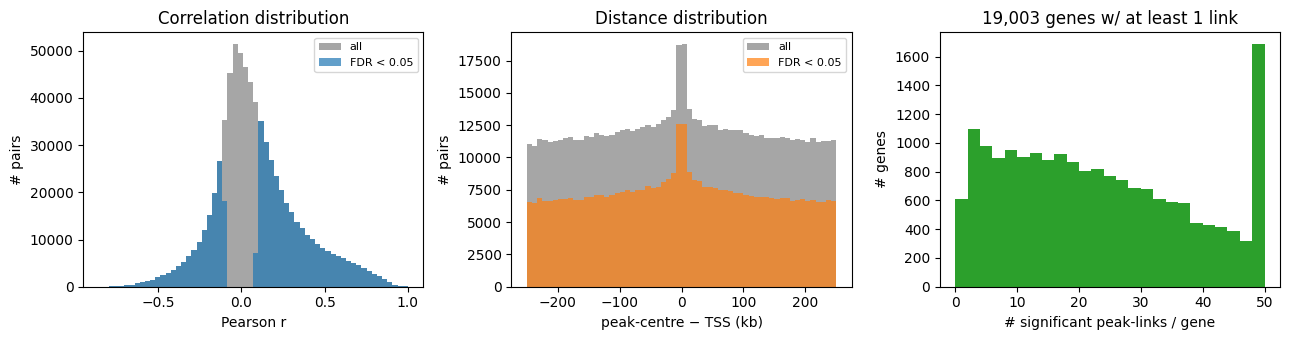

In [8]:
import matplotlib.pyplot as plt

sig = links[links['fdr'] < 0.05]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(links['correlation'], bins=60, color='gray', alpha=0.7, label='all')
axes[0].hist(sig['correlation'],   bins=60, color='C0',   alpha=0.7, label='FDR < 0.05')
axes[0].set_xlabel('Pearson r'); axes[0].set_ylabel('# pairs')
axes[0].set_title('Correlation distribution'); axes[0].legend(fontsize=8)

axes[1].hist(links['distance'] / 1e3,     bins=60, color='gray', alpha=0.7, label='all')
axes[1].hist(sig['distance']   / 1e3,     bins=60, color='C1',   alpha=0.7, label='FDR < 0.05')
axes[1].set_xlabel('peak-centre − TSS (kb)'); axes[1].set_ylabel('# pairs')
axes[1].set_title('Distance distribution'); axes[1].legend(fontsize=8)

# Per-gene link count distribution
links_per_gene = sig.groupby('gene').size().sort_values(ascending=False)
axes[2].hist(links_per_gene.clip(upper=50), bins=np.arange(0, 52, 2), color='C2')
axes[2].set_xlabel('# significant peak-links / gene')
axes[2].set_ylabel('# genes')
axes[2].set_title(f'{len(links_per_gene):,} genes w/ at least 1 link')
plt.tight_layout()
from IPython.display import display
display(fig)
plt.close(fig)

In [9]:
# Show all significant peaks linked to a marker gene of interest
for gene_of_interest in ['CD3D', 'CD19', 'MS4A1', 'GNLY', 'LYZ']:
    sub = sig[sig['gene'] == gene_of_interest]
    if len(sub) == 0:
        continue
    print(f'\
{gene_of_interest}: {len(sub)} significant links')
    print(sub.reindex(sub['correlation'].abs().sort_values(ascending=False).index)
             .head(8)[['peak', 'distance', 'correlation', 'fdr']].to_string(index=False))

CD3D: 52 significant links
                     peak  distance  correlation  fdr
chr11:118337765-118347252      -197     0.882967  0.0
chr11:118304165-118308090    -36578     0.849636  0.0
chr11:118315296-118317685    -26215     0.779693  0.0
chr11:118398435-118402795     57910     0.710349  0.0
chr11:118434093-118439206     93944     0.694896  0.0
chr11:118334526-118336162     -7361     0.672488  0.0
chr11:118142062-118143479   -199935    -0.651616  0.0
chr11:118529661-118533768    189009     0.644498  0.0
CD19: 44 significant links
                   peak  distance  correlation          fdr
chr16:28910024-28911110    -21397     0.913139 0.000000e+00
chr16:28930484-28933437        -4     0.874558 0.000000e+00
chr16:28923628-28926451     -6925     0.711179 0.000000e+00
chr16:28902003-28904135    -28895     0.576940 1.681558e-44
chr16:29007438-29010500     77005    -0.428174 8.183603e-23
chr16:29011125-29015014     81105    -0.419150 8.160589e-22
chr16:28983067-28991072     55105    -0.

## 6. Visualise peak-to-gene links

`epione.pl.plot_peak2gene` produces an arc-style track plot around a gene of interest — **no BigWig files required**. If `group_by=` is supplied, per-category pseudobulk coverage is computed on the fly from the peak matrix.

Design notes:

- Arcs connect each peak's centre to the linked gene's TSS. Red arcs are activating (r > 0), blue are repressing (r < 0). Opacity ∝ |r|, line width ∝ −log₁₀(FDR).
- Peak track: peaks with at least one significant link are highlighted red, the rest grey.
- Gene track: the target gene is drawn in green with a TSS triangle; neighbour genes appear in grey.
- Coverage rows are *optional* — the rest of the figure works from the AnnData + links table alone. If you already have BigWig files, pass them via `bigwig_files={'label': 'path'}`.

/scratch/users/steorra/analysis/omicverse_dev/epione/epione/pl/_peak2gene.py:339: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


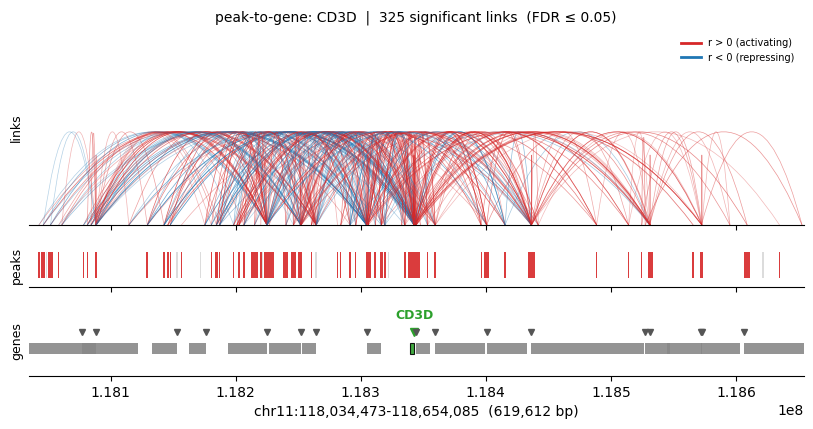

In [10]:
# Minimal mode – just the arcs, peaks, and gene track (no coverage)
from IPython.display import display
fig, _ = ep.pl.plot_peak2gene(
    atac, gene='CD3D',
    gene_annotation=gene_ann,
    fdr_thresh=0.05, min_abs_r=0.3,
    pad_bp=80_000, figsize=(10, 4.5), show=True,
)
display(fig)
plt.close(fig)


/tmp/ipykernel_7927/3735604746.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


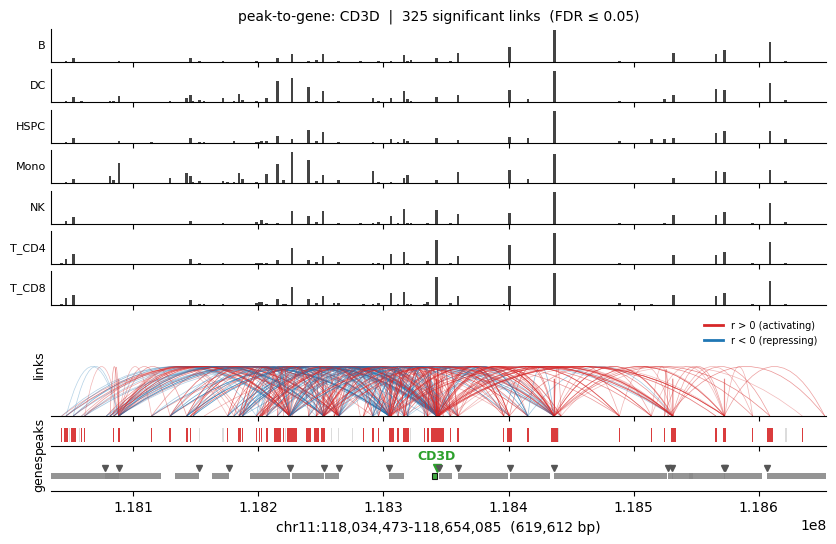

/tmp/ipykernel_7927/3735604746.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


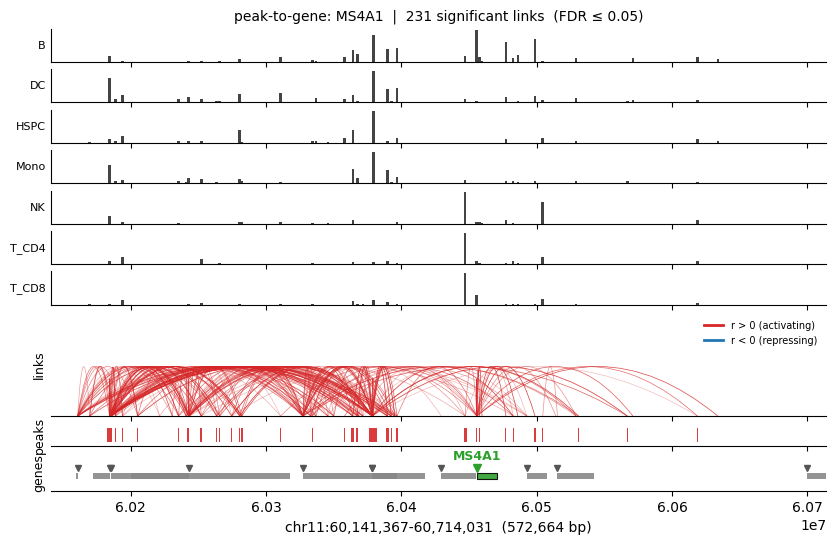

/tmp/ipykernel_7927/3735604746.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


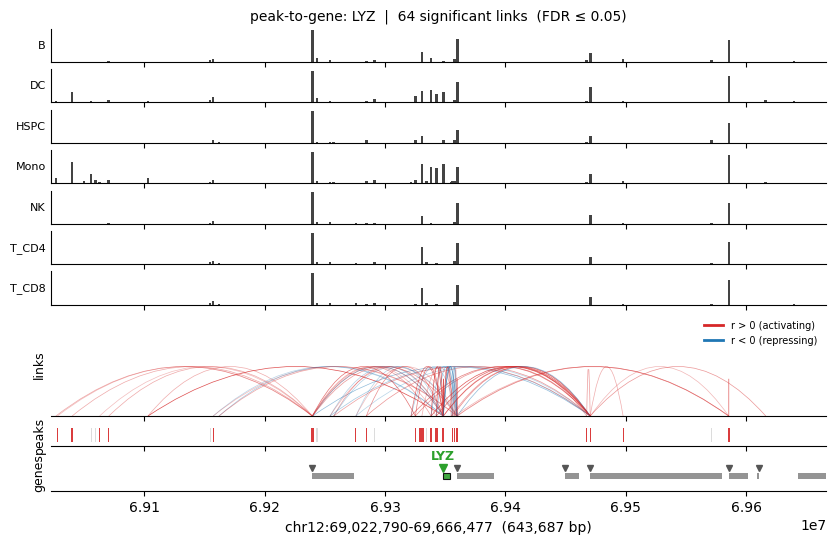

/tmp/ipykernel_7927/3735604746.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


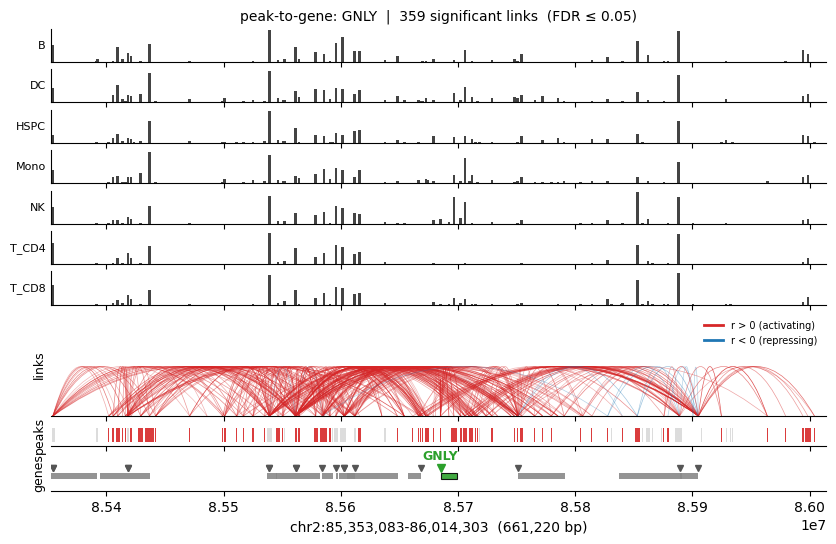

In [11]:
# With per-lineage pseudobulk coverage (computed live from adata.X)
major = {
    'CD4 Naive':'T_CD4','CD4 TCM':'T_CD4','CD4 TEM':'T_CD4','Treg':'T_CD4',
    'CD8 Naive':'T_CD8','CD8 TEM_1':'T_CD8','CD8 TEM_2':'T_CD8','MAIT':'T_CD8','gdT':'T_CD8',
    'Naive B':'B','Memory B':'B','Intermediate B':'B','Plasma':'B',
    'NK':'NK','CD14 Mono':'Mono','CD16 Mono':'Mono','cDC':'DC','pDC':'DC','HSPC':'HSPC',
}
atac.obs['lineage'] = atac.obs['cell_type'].map(major).astype('category')

from IPython.display import display
for gene in ['CD3D', 'MS4A1', 'LYZ', 'GNLY']:
    fig, _ = ep.pl.plot_peak2gene(
        atac, gene=gene,
        group_by='lineage',
        gene_annotation=gene_ann,
        fdr_thresh=0.05, min_abs_r=0.3,
        pad_bp=80_000, figsize=(10, 6), show=False,
    )
    plt.tight_layout()
    display(fig)
    plt.close(fig)


## Notes

- When RNA is unavailable, pass a **gene score / gene activity matrix** instead (e.g. `adata.obsm['X_gene_score']` + `gene_names=`). The rest of the API is identical.
- Memory scales with the number of *candidate pairs*, not cells: a 250 kb window against ~20k genes gives ~20 gene hits / peak, so ≈`n_peaks × 20` float32 values.
- `n_metacells=500, k_neighbors=100` matches ArchR's defaults. Increase both for higher resolution at the cost of more RAM; use fewer for toy datasets.
- Statistics: `t = r * sqrt((n-2) / (1-r²))`; p-values are 2-sided Student-t and converted to FDR via Benjamini–Hochberg over **all** tested pairs.
- Results are deterministic given the same `seed` — the only randomness is in the anchor-cell draw for metacells.